In [1]:
import pandas, sklearn, xgboost, shap
print("Tout est OK")


Tout est OK


In [2]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df["Churn"].value_counts(normalize=True))
df.head()

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df["TotalCharges"].dtype)

mask = df["TotalCharges"].str.strip() == ""
print(mask.sum())
df.loc[mask, ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

str
11


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [4]:
n_avant = len(df)

# TotalCharges: texte -> nombre (espaces vides deviennent NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 11 nouveaux clients (tenure = 0), jamais facturés
df = df.dropna(subset=["TotalCharges"])

# Colonne inutile pour le modèle
df = df.drop(columns=["customerID"])

# Cible en 0/1
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print(f"Avant : {n_avant} lignes | Après : {len(df)} lignes")
print(f"Supprimées : {n_avant - len(df)}")
print(f"Taux de churn : {df['Churn'].mean():.2%}")


Avant : 7043 lignes | Après : 7032 lignes
Supprimées : 11
Taux de churn : 26.58%


Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64


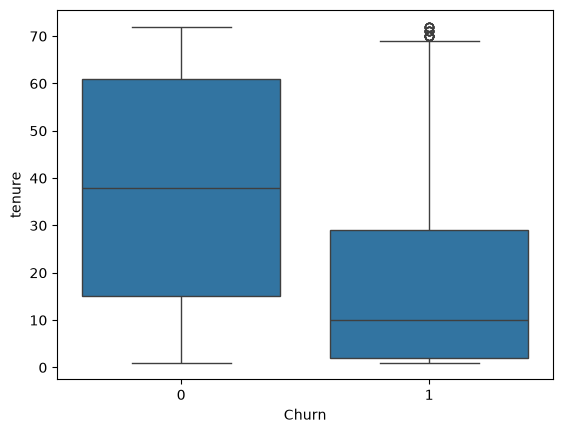

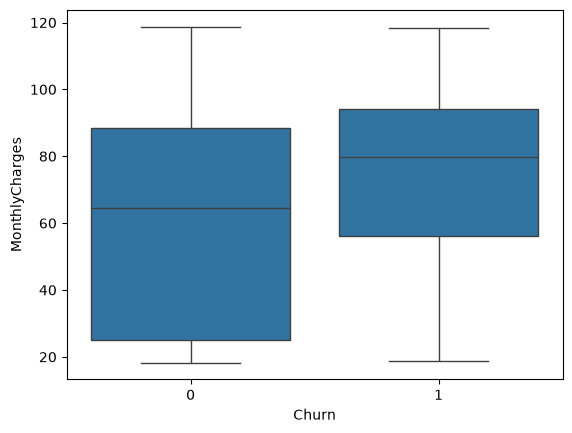

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.groupby("Contract")["Churn"].mean().round(3))

sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()